## Coding Exercise #0308

### 1. Classification with Tree:

### 📦 Bloque de importaciones en Python

Este bloque prepara el entorno para análisis de datos y *machine learning*.

- **`import numpy as np`**  
  Biblioteca fundamental para cálculo numérico y manejo de arreglos y matrices.

- **`import pandas as pd`**  
  Manejo de datos en forma tabular mediante *DataFrames* (similar a Excel).

- **`import matplotlib.pyplot as plt`**  
  Generación de gráficas básicas: líneas, barras, histogramas, dispersión.

- **`import os`**  
  Interacción con el sistema operativo: rutas, carpetas, archivos.

- **`import seaborn as sns`**  
  Visualización estadística avanzada basada en *Matplotlib* (heatmaps, boxplots, etc.).

- **`import warnings`**  
  Control de mensajes de advertencia del sistema.

---

### 🧠 Scikit-learn

```python
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn import metrics, preprocessing
````
* train_test_split: divide los datos en entrenamiento y prueba.

* GridSearchCV: búsqueda automática de hiperparámetros óptimos.

* DecisionTreeClassifier: árbol de decisión para clasificación.

* DecisionTreeRegressor: árbol de decisión para regresión.

* metrics: evaluación del modelo (accuracy, RMSE, etc.).

* preprocessing: escalado y transformación de datos


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn import metrics, preprocessing
warnings.filterwarnings(action='ignore')                  # Turn off the warnings.
%matplotlib inline

## 🏠 Función `load_boston()`

Esta función construye manualmente el conjunto de datos *Boston Housing* a partir de una fuente externa.

```python
def load_boston():
  ````
  El conjunto de datos Boston Housing describe características socioeconómicas y urbanas de distintos distritos de Boston (EE. UU.).
Cada fila representa una zona y las variables incluyen, entre otras:

CRIM: tasa de criminalidad per cápita

ZN: proporción de suelo residencial

INDUS: proporción de suelo industrial

CHAS: proximidad al río Charles (0/1)

NOX: concentración de óxidos nítricos

RM: número promedio de habitaciones

AGE: antigüedad de las viviendas

DIS: distancia a centros de empleo

RAD: accesibilidad a carreteras

TAX: tasa impositiva

In [2]:
def load_boston():
    data_url = "http://lib.stat.cmu.edu/datasets/boston" #escribimos la dirección donde sacaremos los datos
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None) # con la función read_ csv de pandas gauardamos las filas de la tabla separada por columnas debido a que tiene espacios irregulares \s+ se utiliza para especificar uno o mas espacios en blanco, ignorando las 22 filas iniciales y que los datos no tienen encavezados para construir la tabla
    #print(raw_df)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]
    return {'data': data, 'target': target, 'DESCR': 'boston dataset', 'feature_names': ['CRIM','ZN','INDUS','CHAS', 'NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT']}

#### 1.1. Read in data:

In [ ]:
# Go to the directory where the data file is located.
# os.chdir(r'~~')                # Please, replace the path with your own.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Read the already pre-processed data.
df_titanic = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Chapter 5-20250108T203236Z-001/Chapter 5/data_titanic_2.csv', header='infer')

In [ ]:
# Read the already pre-processed data.
#df = pd.read_csv('data_titanic_2.csv', header='infer')

In [5]:
df.shape

(889, 21)

In [6]:
df.head(3)

,Embarked_Q,Embarked_S,Sex_male,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,SibSp_1,...,SibSp_3,SibSp_4,SibSp_5,SibSp_8,Pclass_2,Pclass_3,"Age_(21.0, 30.0]","Age_(30.0, 35.0]","Age_(35.0, 80.0]",Survived
0,False,True,True,False,False,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,0
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,1
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,1


In [7]:
X_titanic = df_titanic.drop(columns=['Survived'])
Y_titanic = df_titanic.Survived

In [9]:
X_train_titanic, X_test_titanic, Y_train_titanic, Y_test_titanic = train_test_split(X_titanic, Y_titanic, test_size=0.3, random_state=1234)

1. Separación de características y objetivo:

X = df.drop(columns=['Survived']):

Aquí se crea la matriz de características, X, eliminando la columna Survived.

De esta forma, X contiene todas las variables independientes (las características que se usarán para predecir el objetivo).

Y = df.Survived:

Aquí se crea el vector objetivo, Y, que contiene la columna Survived.

Esta columna es la variable que queremos predecir (por ejemplo, si un pasajero sobrevivió o no en el Titanic).

2. División en conjuntos de entrenamiento y prueba:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1234):

train_test_split: Es una función que divide los datos en dos conjuntos: uno para entrenar el modelo (train) y otro para probar su rendimiento (test).

test_size=0.3: Esto significa que el 30% de los datos se usará para el conjunto de prueba y el 70% para el entrenamiento.

random_state=1234: Fija una semilla para la aleatorización, asegurando que la división de los datos sea consistente cada vez que se ejecute el código.

¿Qué se logra con esto?

Preparación adecuada: Al separar X y Y, y luego dividirlos en conjuntos de entrenamiento y prueba, se garantiza que el modelo se entrene y evalúe de forma correcta.

Evitar sobreajuste: Al tener un conjunto de prueba independiente, puedes medir de manera objetiva cómo se comporta el modelo con datos que no ha visto antes.

Evaluación del rendimiento: Esta separación es fundamental para evaluar de forma justa y precisa la capacidad del modelo para generalizar a nuevos datos.

En resumen, estas líneas preparan tus datos de manera que el modelo pueda entrenarse y evaluarse de manera efectiva y confiable

optimización de hiperparametros de arbol

#### 1.2. Tree hyperparameter optimization:

In [10]:
depth_grid = np.arange(1,21)
min_samples_leaf_grid = np.arange(10,31)
max_leaf_nodes_grid = np.arange(2,21)
parameters_titanic = {'max_depth':depth_grid, 'min_samples_leaf':min_samples_leaf_grid, 'max_leaf_nodes':max_leaf_nodes_grid}
gridCV = GridSearchCV(DecisionTreeClassifier(), parameters_titanic, cv=10, n_jobs = -1)
gridCV.fit(X_train_titanic, Y_train_titanic);
best_depth_titanic = gridCV.best_params_['max_depth']
best_min_samples_leaf_titanic = gridCV.best_params_['min_samples_leaf']
best_max_leaf_nodes_titanic = gridCV.best_params_['max_leaf_nodes']

* 1.depth_grid = np.arange(1,21)

Aquí se está creando un rango de valores para el hiperparámetro max_depth.

np.arange(1,21) genera una secuencia de números enteros desde 1 hasta 20 (21 no incluido).

max_depth controla la profundidad máxima del árbol de decisión. Un max_depth mayor permite que el árbol sea más complejo, mientras que un valor más bajo lo limita y puede evitar el sobreajuste.

* 2. min_samples_leaf_grid = np.arange(10,31)

Aquí se define un rango de valores para el hiperparámetro min_samples_leaf.

np.arange(10,31) genera números enteros desde 10 hasta 30 (31 no incluido).

min_samples_leaf determina el número mínimo de muestras que debe tener una hoja del árbol.

Un valor mayor de min_samples_leaf hace que las hojas del árbol tengan más muestras, lo que puede ayudar a evitar el sobreajuste.

* 3. max_leaf_nodes_grid = np.arange(2,21)

Se crea un rango de valores para el hiperparámetro max_leaf_nodes.

np.arange(2,21) genera números enteros desde 2 hasta 20 (21 no incluido).

max_leaf_nodes limita el número máximo de nodos hoja que puede tener el árbol.

Controlar este parámetro ayuda a simplificar el árbol y evitar que crezca en exceso.

* 4. parameters = {'max_depth':depth_grid, 'min_samples_leaf':min_samples_leaf_grid, 'max_leaf_nodes':max_leaf_nodes_grid}

Aquí se crea un diccionario llamado parameters que agrupa todos estos rangos de hiperparámetros.

Este diccionario se utiliza en técnicas de búsqueda de hiperparámetros, como GridSearchCV, para probar todas las combinaciones posibles de estos valores y encontrar la mejor configuración para el modelo.

In [12]:
gridCV = GridSearchCV(DecisionTreeClassifier(), parameters, cv=10, n_jobs = -1)        # estimator = an instance of DecisionTreeClassifier. cv=validación cruzada n_jobs acelera el proceso al usar más núcleos, pero puede consumir más recursos.La clave está en encontrar un equilibrio que se ajuste a tus necesidades y a los recursos disponibles.
gridCV.fit(X_train, Y_train);
best_depth = gridCV.best_params_['max_depth']
best_min_samples_leaf = gridCV.best_params_['min_samples_leaf']
best_max_leaf_nodes = gridCV.best_params_['max_leaf_nodes']

1. gridCV = GridSearchCV(DecisionTreeClassifier(), parameters, cv=10, n_jobs = -1)

GridSearchCV: Es una clase de scikit-learn que realiza una búsqueda exhaustiva sobre un espacio de hiperparámetros especificado.

DecisionTreeClassifier(): Es el estimador, en este caso un clasificador de árbol de decisión.

parameters: Es el diccionario con los rangos de hiperparámetros que definimos anteriormente (max_depth, min_samples_leaf, max_leaf_nodes).

cv=10: Especifica que se usará validación cruzada de 10 pliegues. Esto significa que los datos se dividirán en 10 partes, y el modelo se entrenará y evaluará 10 veces, cada vez con una parte diferente como conjunto de prueba y el resto como entrenamiento.

n_jobs = -1: Utiliza todos los núcleos del procesador disponibles para acelerar el proceso de búsqueda.

En conjunto, esta línea configura una búsqueda exhaustiva para encontrar la mejor combinación de hiperparámetros.

2. gridCV.fit(X_train, Y_train)

fit: Es el método que entrena el GridSearchCV con los datos de entrenamiento (X_train y Y_train).

Durante este proceso, se entrenan múltiples modelos con diferentes combinaciones de hiperparámetros y se evalúan mediante validación cruzada.

3. best_depth = gridCV.best_params_['max_depth']

best_params_: Es un atributo del GridSearchCV que contiene el conjunto de hiperparámetros que resultaron en el mejor rendimiento.

Aquí se extrae el valor óptimo para max_depth.

4. best_min_samples_leaf = gridCV.best_params_['min_samples_leaf']

De manera similar, se extrae el mejor valor para min_samples_leaf.

5. best_max_leaf_nodes = gridCV.best_params_['max_leaf_nodes']

Y de igual forma, se obtiene el valor óptimo para max_leaf_nodes.

¿Qué se logra con estas líneas?

Optimización de hiperparámetros: Al final del proceso, tienes los valores de max_depth, min_samples_leaf y max_leaf_nodes que mejoran el rendimiento del modelo en base a la validación cruzada.

Mejora del modelo: Con estos mejores hiperparámetros, el árbol de decisión debería generalizar mejor y evitar el sobreajuste.

Reproducibilidad: La configuración óptima obtenida es consistente y te permite entrenar modelos más robustos.

En resumen, estas líneas configuran y ejecutan una búsqueda exhaustiva para optimizar los hiperparámetros de un árbol de decisión, y finalmente extraen la mejor configuración encontrada

In [13]:
print("Tree best depth : " + str(best_depth_titanic))
print("Tree best min_samples_leaf : " + str(best_min_samples_leaf_titanic))
print("Tree best max_leaf_nodes : " + str(best_max_leaf_nodes_titanic))

Tree best depth : 3
Tree best min_samples_leaf : 23
Tree best max_leaf_nodes : 6


Explicación detallada:

print("Tree best depth : " + str(best_depth)):

best_depth: Es el valor óptimo para el hiperparámetro max_depth que se encontró durante la búsqueda.

str(best_depth): Convierte el valor de best_depth a una cadena de texto para poder concatenarlo con el mensaje.

print(...): Imprime en la consola el mensaje que indica cuál es la profundidad óptima del árbol de decisión.

print("Tree best min_samples_leaf : " + str(best_min_samples_leaf)):

best_min_samples_leaf: Es el valor óptimo para el hiperparámetro min_samples_leaf, que determina el número mínimo de muestras que debe tener una hoja del árbol.

El proceso es el mismo: se convierte el valor a texto y se imprime el mensaje con el valor óptimo.

print("Tree best max_leaf_nodes : " + str(best_max_leaf_nodes)):

best_max_leaf_nodes: Es el valor óptimo para el hiperparámetro max_leaf_nodes, que limita el número máximo de nodos hoja en el árbol.

Igual que antes, se convierte el valor a cadena y se imprime el mensaje final con el valor óptimo encontrado.

¿Qué se logra con estas líneas?

Comunicación de resultados: Estas líneas permiten ver de manera clara y directa cuáles fueron los mejores valores de los hiperparámetros tras la búsqueda.

Interpretación: Al conocer estos valores óptimos, puedes entender mejor cómo se ha ajustado el modelo para obtener un buen rendimiento.

Referencia para futuros entrenamientos: Estos valores óptimos pueden utilizarse para entrenar el modelo final y asegurarse de que tenga un buen desempeño en nuevos datos.

En conjunto, estas líneas son una forma de resumir y presentar los mejores resultados obtenidos en la búsqueda de hiperparámetros, facilitando la interpretación y el siguiente paso en el proceso de modelado.

In [14]:
DTC_best = DecisionTreeClassifier(max_depth=best_depth_titanic,min_samples_leaf=best_min_samples_leaf_titanic,max_leaf_nodes=best_max_leaf_nodes_titanic)
DTC_best.fit(X_train_titanic, Y_train_titanic);
Y_pred_titanic = DTC_best.predict(X_test_titanic)
print( "Tree best accuracy : " + str(np.round(metrics.accuracy_score(Y_test_titanic,Y_pred_titanic),3)))

Tree best accuracy : 0.82


1. Creación del modelo con los mejores hiperparámetros:

DTC_best = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, max_leaf_nodes=best_max_leaf_nodes):

Aquí se crea una instancia del clasificador de árbol de decisión (DecisionTreeClassifier), pero esta vez con los hiperparámetros óptimos que se encontraron anteriormente:

max_depth=best_depth: Profundidad máxima del árbol.

min_samples_leaf=best_min_samples_leaf: Número mínimo de muestras en una hoja.

max_leaf_nodes=best_max_leaf_nodes: Número máximo de nodos hoja.

De esta manera, se aprovechan los mejores parámetros para obtener el modelo más efectivo.

2. Entrenamiento del modelo:

DTC_best.fit(X_train, Y_train):

Aquí se entrena el modelo con los datos de entrenamiento (X_train y Y_train).

El modelo aprende los patrones y relaciones entre las características y la variable objetivo.

3. Predicción con el modelo:

Y_pred = DTC_best.predict(X_test):

Aquí se utiliza el modelo entrenado para hacer predicciones sobre el conjunto de prueba (X_test).

Y_pred contiene las predicciones del modelo para cada muestra en el conjunto de prueba.

4. Evaluación del modelo:

print("Tree best accuracy : " + str(np.round(metrics.accuracy_score(Y_test, Y_pred), 3))):

metrics.accuracy_score(Y_test, Y_pred): Calcula la precisión del modelo, es decir, la proporción de predicciones correctas en el conjunto de prueba.

np.round(..., 3): Redondea la precisión a tres decimales para que la presentación sea más clara.

print(...): Imprime la precisión obtenida, mostrando cuánto de preciso es el modelo con los mejores hiperparámetros.

¿Qué se logra con estas líneas?

Entrenamiento óptimo: Al usar los mejores hiperparámetros, se entrena un modelo que tiene un mejor rendimiento y generaliza de forma más efectiva a nuevos datos.

Evaluación precisa: La predicción y la evaluación en el conjunto de prueba permiten medir el rendimiento del modelo de forma objetiva.

Interpretación de resultados: Al mostrar la precisión final, se puede ver claramente qué tan bien se comporta el modelo con los datos no vistos.

En resumen, estas líneas permiten entrenar, predecir y evaluar un modelo de árbol de decisión de manera óptima y obtener una medida clara de su rendimiento.


# Visualización

##Matriz de Confusión

* Muestra los verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos
* Te permite ver qué tan bien clasifica el modelo entre sobrevivientes (1) y no sobrevivientes (0)

In [45]:
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                            classification_report, mean_squared_error,
                            mean_absolute_error, r2_score)
from scipy import stats
from sklearn.tree import plot_tree # Import plot_tree

# Configuración de estilo para gráficas más atractivas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
fig = plt.figure(figsize=(20, 15))

# Calculate prediction probabilities
Y_pred_proba_titanic = DTC_best.predict_proba(X_test_titanic)[:, 1]

# 1. MATRIZ DE CONFUSIÓN
ax1 = plt.subplot(3, 3, 1)
cm = confusion_matrix(Y_test_titanic, Y_pred_titanic)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Sobrevivió', 'Sobrevivió'],
            yticklabels=['No Sobrevivió', 'Sobrevivió'])
plt.title('Matriz de Confusión - Titanic', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')

ValueError: X has 13 features, but DecisionTreeClassifier is expecting 20 features as input.

<Figure size 2000x1500 with 0 Axes>

##Curva ROC y AUC

* Evalúa la capacidad del modelo para discriminar entre clases
* El área bajo la curva (AUC) te da una métrica de rendimiento global

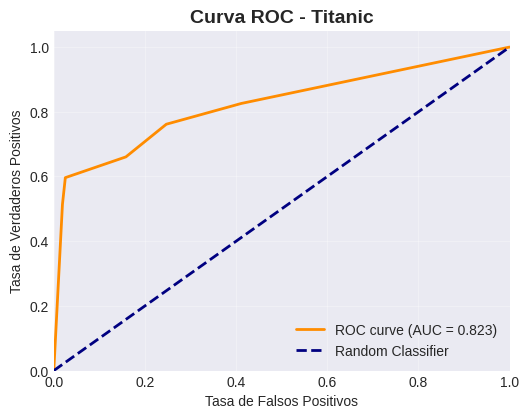

In [25]:
# Configuración de estilo para gráficas más atractivas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# 2. CURVA ROC
ax2 = plt.subplot(3, 3, 2)
fpr, tpr, thresholds = roc_curve(Y_test_titanic, Y_pred_proba_titanic)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Titanic', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

##Importancia de Variables

* Gráfico de barras mostrando qué features contribuyen más a las predicciones
Fundamental para interpretabilidad

Text(0, 0.5, 'Variable')

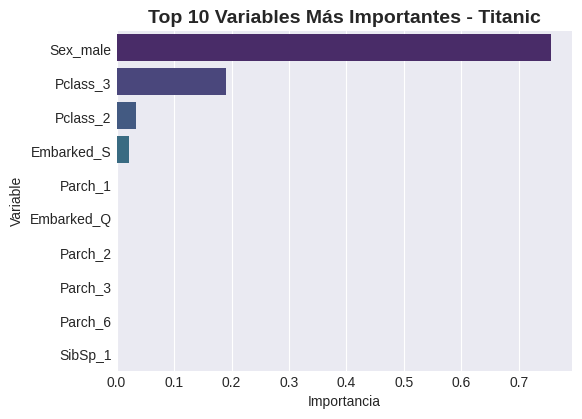

In [26]:
# Configuración de estilo para gráficas más atractivas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# 3. IMPORTANCIA DE VARIABLES
ax3 = plt.subplot(3, 3, 3)
feature_importance = pd.DataFrame({
    'feature': X_titanic.columns,
    'importance': DTC_best.feature_importances_
}).sort_values('importance', ascending=False).head(10)

sns.barplot(data=feature_importance, y='feature', x='importance', palette='viridis')
plt.title('Top 10 Variables Más Importantes - Titanic', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.ylabel('Variable')

## Distribución de Probabilidades
* Separando sobrevivientes vs no sobrevivientes

**¿Qué muestra?**

Dos histogramas superpuestos:
- **Rojo:** Probabilidades que dio el modelo a personas que NO sobrevivieron
- **Verde:** Probabilidades que dio el modelo a personas que SÍ sobrevivieron

## Buen modelo: Las distribuciones están separadas

* Rojos concentrados cerca de 0.0-0.3
* Verdes concentrados cerca de 0.7-1.0


## Mal modelo: Se traslapan mucho (no puede distinguir)

Ejemplo real:

* Persona real: NO sobrevivió → Modelo predijo: 15% de supervivencia ✓
* Persona real: SÍ sobrevivió → Modelo predijo: 85% de supervivencia ✓
* Persona real: NO sobrevivió → Modelo predijo: 80% de supervivencia ✗ (error)


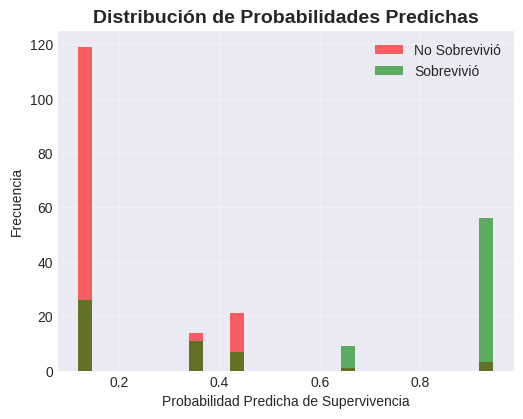

In [27]:
# Configuración de estilo para gráficas más atractivas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# 4. DISTRIBUCIÓN DE PROBABILIDADES PREDICHAS
ax4 = plt.subplot(3, 3, 4)
plt.hist(Y_pred_proba_titanic[Y_test_titanic == 0], bins=30, alpha=0.6, label='No Sobrevivió', color='red')
plt.hist(Y_pred_proba_titanic[Y_test_titanic == 1], bins=30, alpha=0.6, label='Sobrevivió', color='green')
plt.xlabel('Probabilidad Predicha de Supervivencia')
plt.ylabel('Frecuencia')
plt.title('Distribución de Probabilidades Predichas', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

##Visualización del Árbol de Decisión

* Muestra la estructura completa del árbol con sus reglas de decisión
* Te permite entender qué variables son más importantes y cómo se dividen

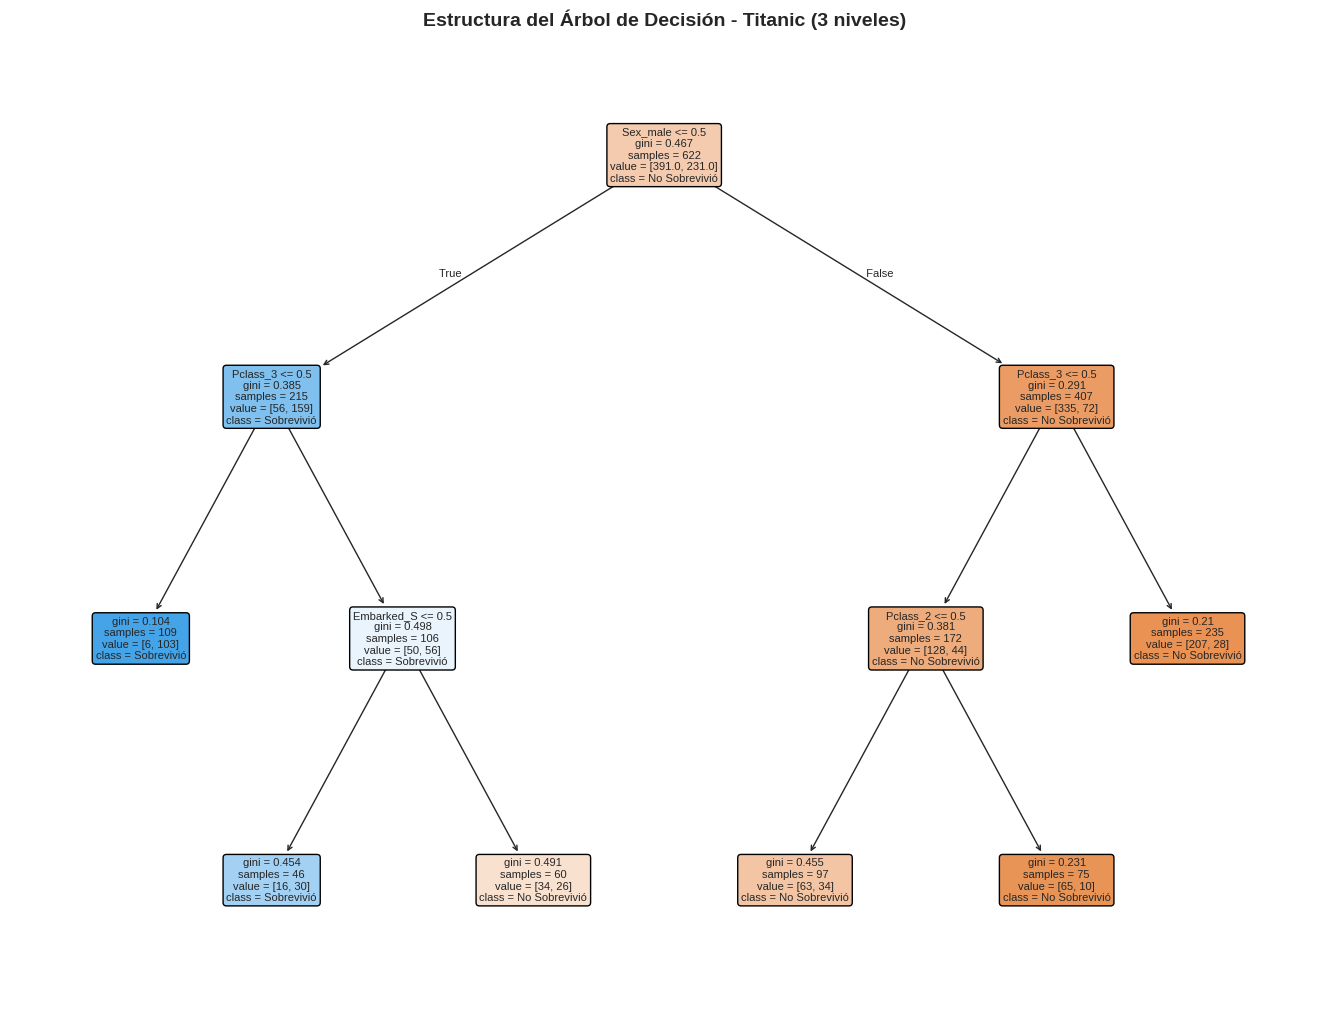

In [28]:
# Configuración de estilo para gráficas más atractivas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# 5. ÁRBOL DE DECISIÓN (simplificado)
ax5 = plt.subplot(3, 3, (5, 9))
plot_tree(DTC_best,
          feature_names=X_titanic.columns,
          class_names=['No Sobrevivió', 'Sobrevivió'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3)  # Mostramos solo 3 niveles para mejor visualización
plt.title('Estructura del Árbol de Decisión - Titanic (3 niveles)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizaciones_titanic.png', dpi=300, bbox_inches='tight')
plt.show()

##Reporte de Clasificación (texto visual)

* Precision, Recall, F1-Score por clase

In [29]:
# REPORTE DE CLASIFICACIÓN
print("\n" + "="*80)
print("REPORTE DE CLASIFICACIÓN - TITANIC")
print("="*80)
print(classification_report(Y_test_titanic, Y_pred_titanic,
                              target_names=['No Sobrevivió', 'Sobrevivió']))


REPORTE DE CLASIFICACIÓN - TITANIC
               precision    recall  f1-score   support

No Sobrevivió       0.78      0.97      0.87       158
   Sobrevivió       0.94      0.60      0.73       109

     accuracy                           0.82       267
    macro avg       0.86      0.79      0.80       267
 weighted avg       0.84      0.82      0.81       267



### 2. Regression with Tree:

#### 2.1. Read in data:

In [32]:
data = load_boston()

In [33]:
# Display the description on the data.
print(data['DESCR'])

boston dataset


In [34]:
# The explanatory variables.
X = data['data']
header = data['feature_names']

In [35]:
# The response variable.
# This is a numeric variable representing the house price.
Y = data['target']
Y = Y.reshape(-1, 1)

In [50]:
#
feature_names = data['feature_names']

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1234)

#### 2.2. Convert the data into a DataFrame and explore:

In [37]:
df = pd.DataFrame(np.append(X,Y,axis = 1))
df.columns = list(header)+['PRICE']

In [38]:
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [39]:
# Pair-wise correlation matrix.
np.round(df.corr(),2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
CRIM,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,-0.39,0.46,-0.39
ZN,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,0.18,-0.41,0.36
INDUS,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,-0.36,0.60,-0.48
CHAS,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,0.05,-0.05,0.18
NOX,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,-0.38,0.59,-0.43
RM,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,0.13,-0.61,0.70
AGE,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,-0.27,0.60,-0.38
DIS,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,0.29,-0.50,0.25
RAD,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,-0.44,0.49,-0.38
TAX,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,-0.44,0.54,-0.47


#### 2.3. Tree hyperparameter optimization:

In [40]:
depth_grid = np.arange(1,21)
min_samples_leaf_grid = np.arange(10,31)
max_leaf_nodes_grid = np.arange(2,21)
parameters = {'max_depth':depth_grid, 'min_samples_leaf':min_samples_leaf_grid, 'max_leaf_nodes':max_leaf_nodes_grid}

In [41]:
gridCV = GridSearchCV(DecisionTreeRegressor(), parameters, cv=10, n_jobs = -1)      # estimator = an instance of DecisionTreeRegressor.
gridCV.fit(X_train, Y_train)
best_depth = gridCV.best_params_['max_depth']
best_min_samples_leaf = gridCV.best_params_['min_samples_leaf']
best_max_leaf_nodes = gridCV.best_params_['max_leaf_nodes']

In [42]:
print("Tree best depth : " + str(best_depth))
print("Tree best min_samples_leaf : " + str(best_min_samples_leaf))
print("Tree best max_leaf_nodes : " + str(best_max_leaf_nodes))

Tree best depth : 7
Tree best min_samples_leaf : 15
Tree best max_leaf_nodes : 14


In [55]:
DTR_best = DecisionTreeRegressor(max_depth=best_depth,min_samples_leaf=best_min_samples_leaf,max_leaf_nodes=best_max_leaf_nodes)
DTR_best.fit(X_train, Y_train)
Y_pred = DTR_best.predict(X_test)
print( "Tree best RMSE : " + str(np.round(np.sqrt(metrics.mean_squared_error(Y_test,Y_pred)),3)))
residuals = Y_test - Y_pred

Tree best RMSE : 4.113


In [60]:
# Métricas - CALCULAR ANTES DE LAS VISUALIZACIONES
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"\nMejores parámetros: {DTR_best}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R² Score: {r2:.3f}")



Mejores parámetros: DecisionTreeRegressor(max_depth=np.int64(7), max_leaf_nodes=np.int64(14),
                      min_samples_leaf=np.int64(15))
RMSE: 4.113
MAE: 2.802
R² Score: 0.816


NOTE: We can compare the above result with that obtained using linear regression where the RMSE was 5.33.

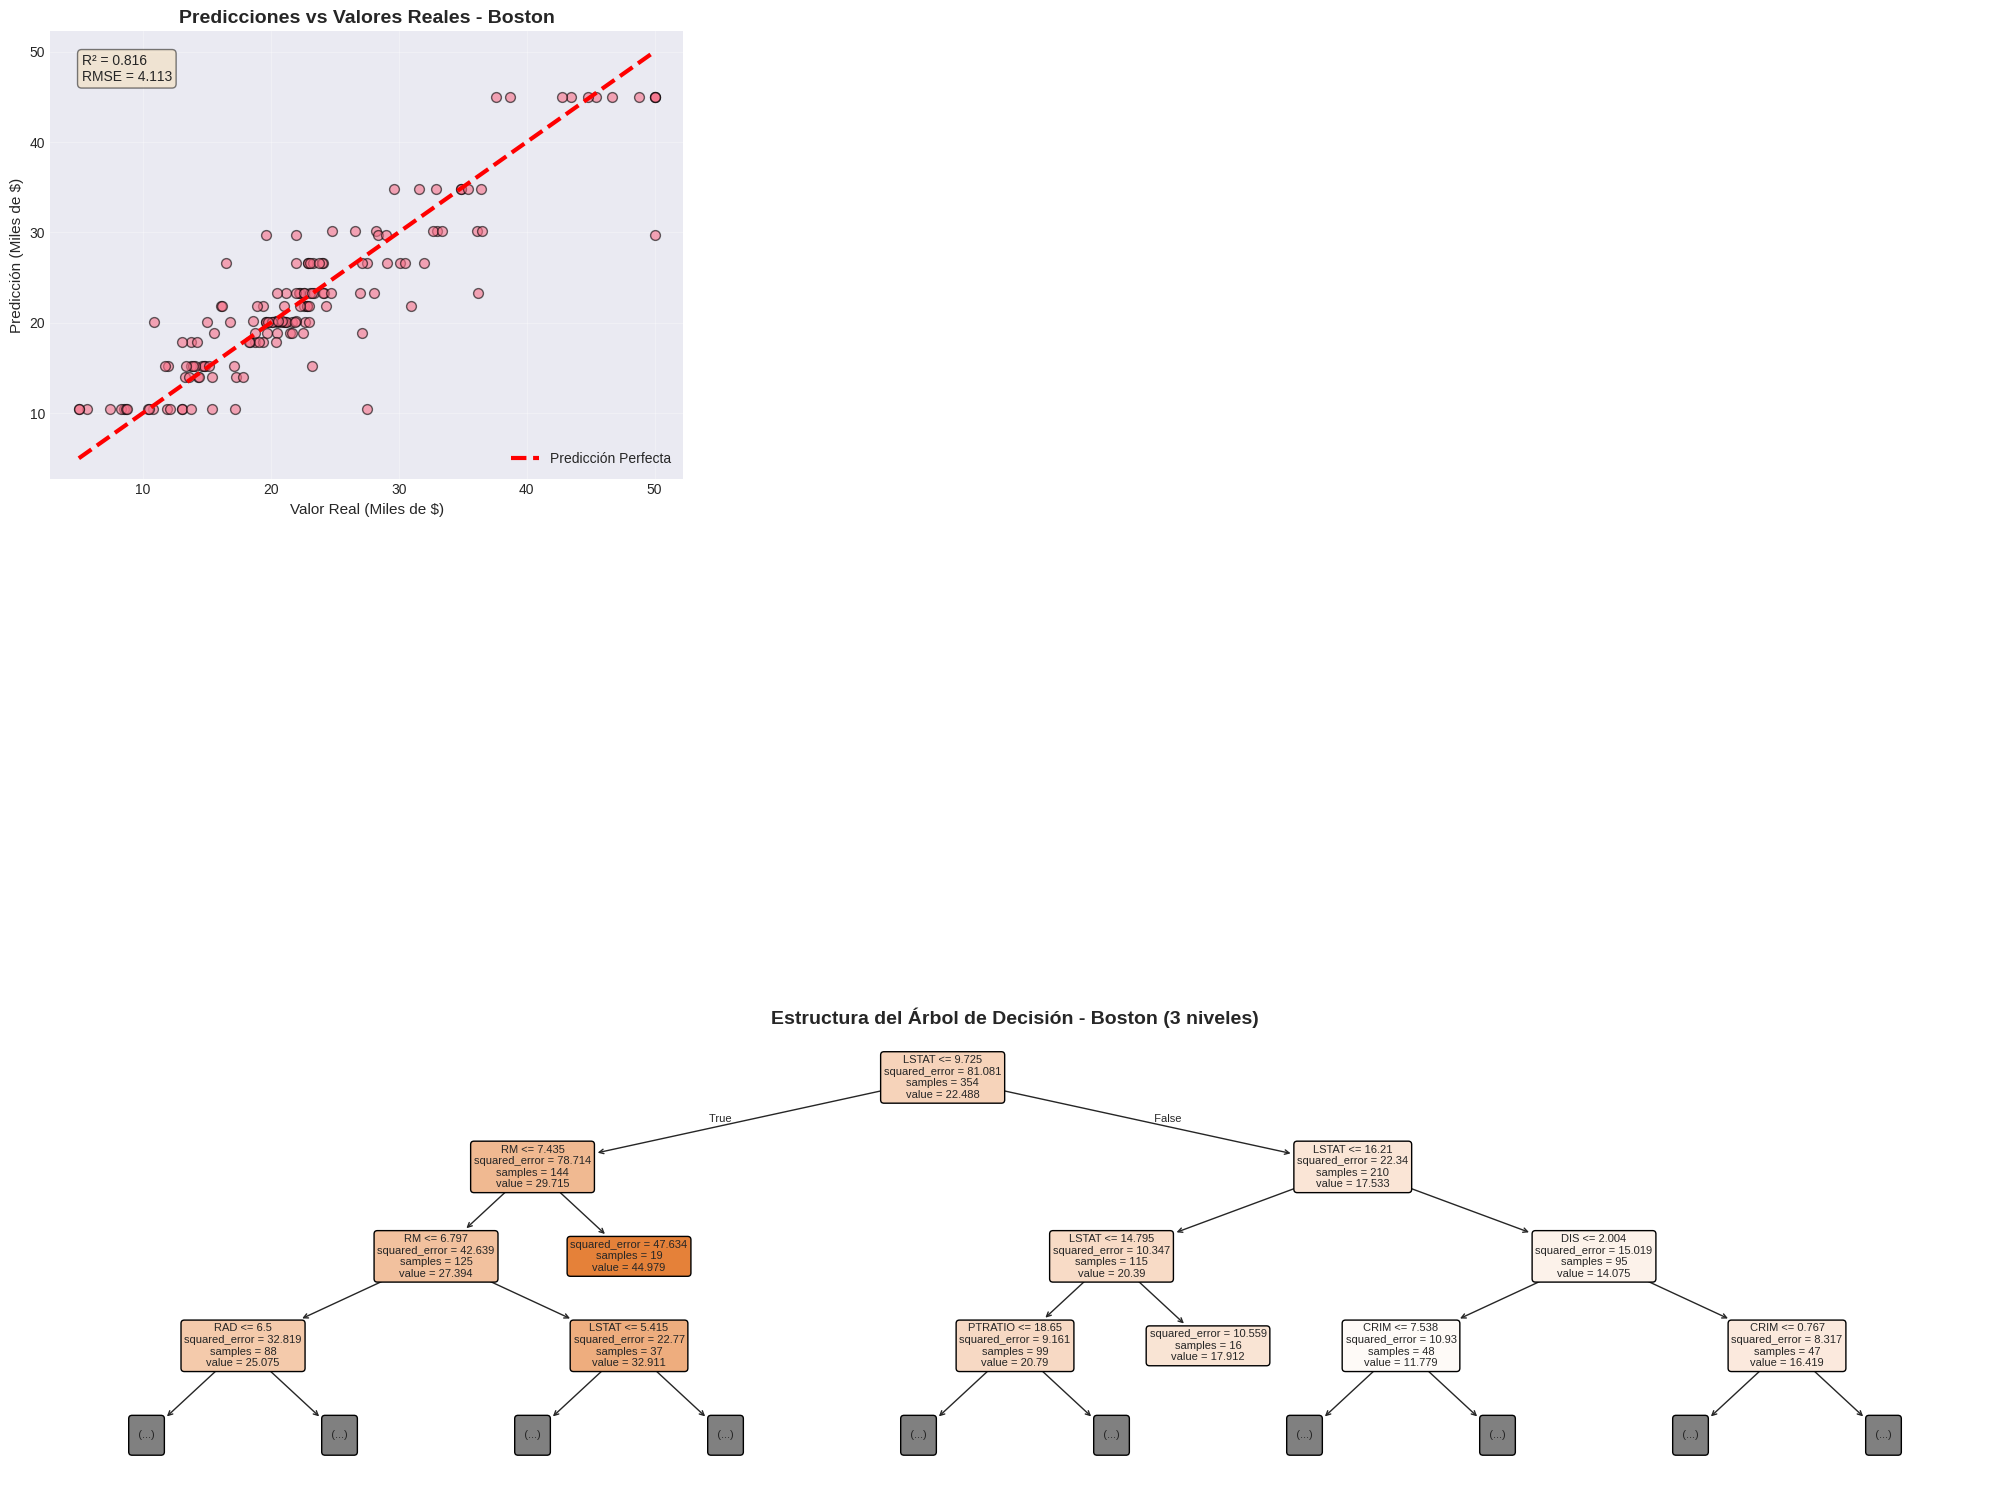

In [66]:
#------------------------------------------------------------------------------
# VISUALIZACIONES BOSTON
#------------------------------------------------------------------------------

fig = plt.figure(figsize=(20, 15))

# 1. PREDICCIONES VS VALORES REALES
ax1 = plt.subplot(3, 3, 1)
plt.scatter(Y_test, Y_pred, alpha=0.6, edgecolors='k', s=50)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         'r--', lw=3, label='Predicción Perfecta')
plt.xlabel('Valor Real (Miles de $)', fontsize=11)
plt.ylabel('Predicción (Miles de $)', fontsize=11)
plt.title('Predicciones vs Valores Reales - Boston', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
# Añadir métricas al gráfico
plt.text(0.05, 0.95, f'R² = {r2:.3f}\nRMSE = {rmse:.3f}',
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


# 7. ÁRBOL DE DECISIÓN (simplificado)
ax7 = plt.subplot(3, 3, (7, 9))
plot_tree(DTR_best,
          feature_names=feature_names,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3)  # Mostramos solo 3 niveles
plt.title('Estructura del Árbol de Decisión - Boston (3 niveles)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizaciones_boston.png', dpi=300, bbox_inches='tight')
plt.show()
